In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

2026-03-24 14:09:36.399221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774361376.620492      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774361376.682351      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774361377.212652      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774361377.212697      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774361377.212700      55 computation_placer.cc:177] computation placer alr

In [2]:
# =========================
# 1. Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# =========================
# 2. Paths
# =========================
CSV_PATH = "/kaggle/input/competitions/diabetic-retinopathy-detection/trainLabels.csv.zip"
IMG_DIR = "/kaggle/input/datasets/josephrynkiewicz/diabetic-retinopathy-train-unzipped/train"


In [4]:
# =========================
# 3. Config
# =========================
IMG_SIZES = [224, 246, 269]   # base, +10%, +20%
BATCH_SIZE = 32
EPOCHS = 3
THRESHOLD = 0.5
MAX_SAMPLES = 4000            # reduce to 2000 if still slow

In [5]:
# =========================
# Imports & Config
# =========================
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Ensure these match your notebook's requirements
IMG_SIZES = [224, 246, 269]
THRESHOLD = 0.5

In [6]:
# =========================
# 4. Load data
# =========================
df = pd.read_csv(CSV_PATH)

# binary label: 0 = No DR, 1 = DR present
df["Label"] = (df["level"] > 0).astype(int)
df["filepath"] = df["image"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.jpeg"))

# keep only files that exist
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

if len(df) == 0:
    raise ValueError("No images found. Check Kaggle dataset paths.")

# smaller stratified sample for speed
if MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df0 = df[df["Label"] == 0]
    df1 = df[df["Label"] == 1]

    n0 = int(MAX_SAMPLES * len(df0) / len(df))
    n1 = MAX_SAMPLES - n0

    df0 = df0.sample(n=min(n0, len(df0)), random_state=SEED)
    df1 = df1.sample(n=min(n1, len(df1)), random_state=SEED)

    df = pd.concat([df0, df1], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Total usable images:", len(df))
print("\nOriginal class distribution:")
print(df["Label"].value_counts())

Total usable images: 4000

Original class distribution:
Label
0    2939
1    1061
Name: count, dtype: int64


In [7]:
# =========================
# 5. Split data
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["Label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain distribution BEFORE balancing:")
print(train_df["Label"].value_counts())



Split sizes:
Train: 2800
Val  : 600
Test : 600

Train distribution BEFORE balancing:
Label
0    2057
1     743
Name: count, dtype: int64


In [8]:
# =========================
# 6. Balance only training set
# =========================
def balance_train_dataframe(df_train, label_col="Label", seed=42):
    df0 = df_train[df_train[label_col] == 0].copy()
    df1 = df_train[df_train[label_col] == 1].copy()

    if len(df0) == 0 or len(df1) == 0:
        raise ValueError("Training split has only one class. Increase MAX_SAMPLES.")

    if len(df0) > len(df1):
        df1_up = df1.sample(n=len(df0), replace=True, random_state=seed)
        balanced = pd.concat([df0, df1_up], axis=0)
    else:
        df0_up = df0.sample(n=len(df1), replace=True, random_state=seed)
        balanced = pd.concat([df0_up, df1], axis=0)

    balanced = balanced.sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced

train_balanced_df = balance_train_dataframe(train_df, label_col="Label", seed=SEED)

print("\nTrain distribution AFTER balancing:")
print(train_balanced_df["Label"].value_counts())


Train distribution AFTER balancing:
Label
0    2057
1    2057
Name: count, dtype: int64


In [9]:
# =========================
# 7. Enhancement function
# =========================
def enhance_retina_rgb(img):
    """
    img: RGB uint8
    """
    img = img.astype(np.uint8)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=2)
    sharp = cv2.addWeighted(img, 1.2, blur, -0.2, 0)

    return np.clip(sharp, 0, 255).astype(np.uint8)

def read_image_rgb(path, target_size):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img

# =========================
# 7. Enhancement functions
# =========================
def enhance_retina_experimental(img, mode='clahe_gray'):
    """
    Experimental enhancements aimed at highlighting DR features 
    to minimize false negatives.
    """
    img = img.astype(np.uint8)
    
    if mode == 'clahe_gray':
        # Hypothesis: Removing color clarifies vessel structures and lesions
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        # Convert back to 3-channel for model compatibility
        return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    elif mode == 'green_channel':
        # Hypothesis: Green channel often provides highest contrast for pathology
        green = img[:, :, 1]
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(green)
        return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    elif mode == 'ben_graham':
        # Normalizes lighting across different fundus cameras
        img_blur = cv2.GaussianBlur(img, (0, 0), 10)
        enhanced = cv2.addWeighted(img, 4, img_blur, -4, 128)
        return enhanced

    # Default RGB Enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=2)
    sharp = cv2.addWeighted(img, 1.2, blur, -0.2, 0)
    return np.clip(sharp, 0, 255).astype(np.uint8)

def read_image_custom(path, target_size, mode='clahe_gray'):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return enhance_retina_experimental(img, mode=mode)



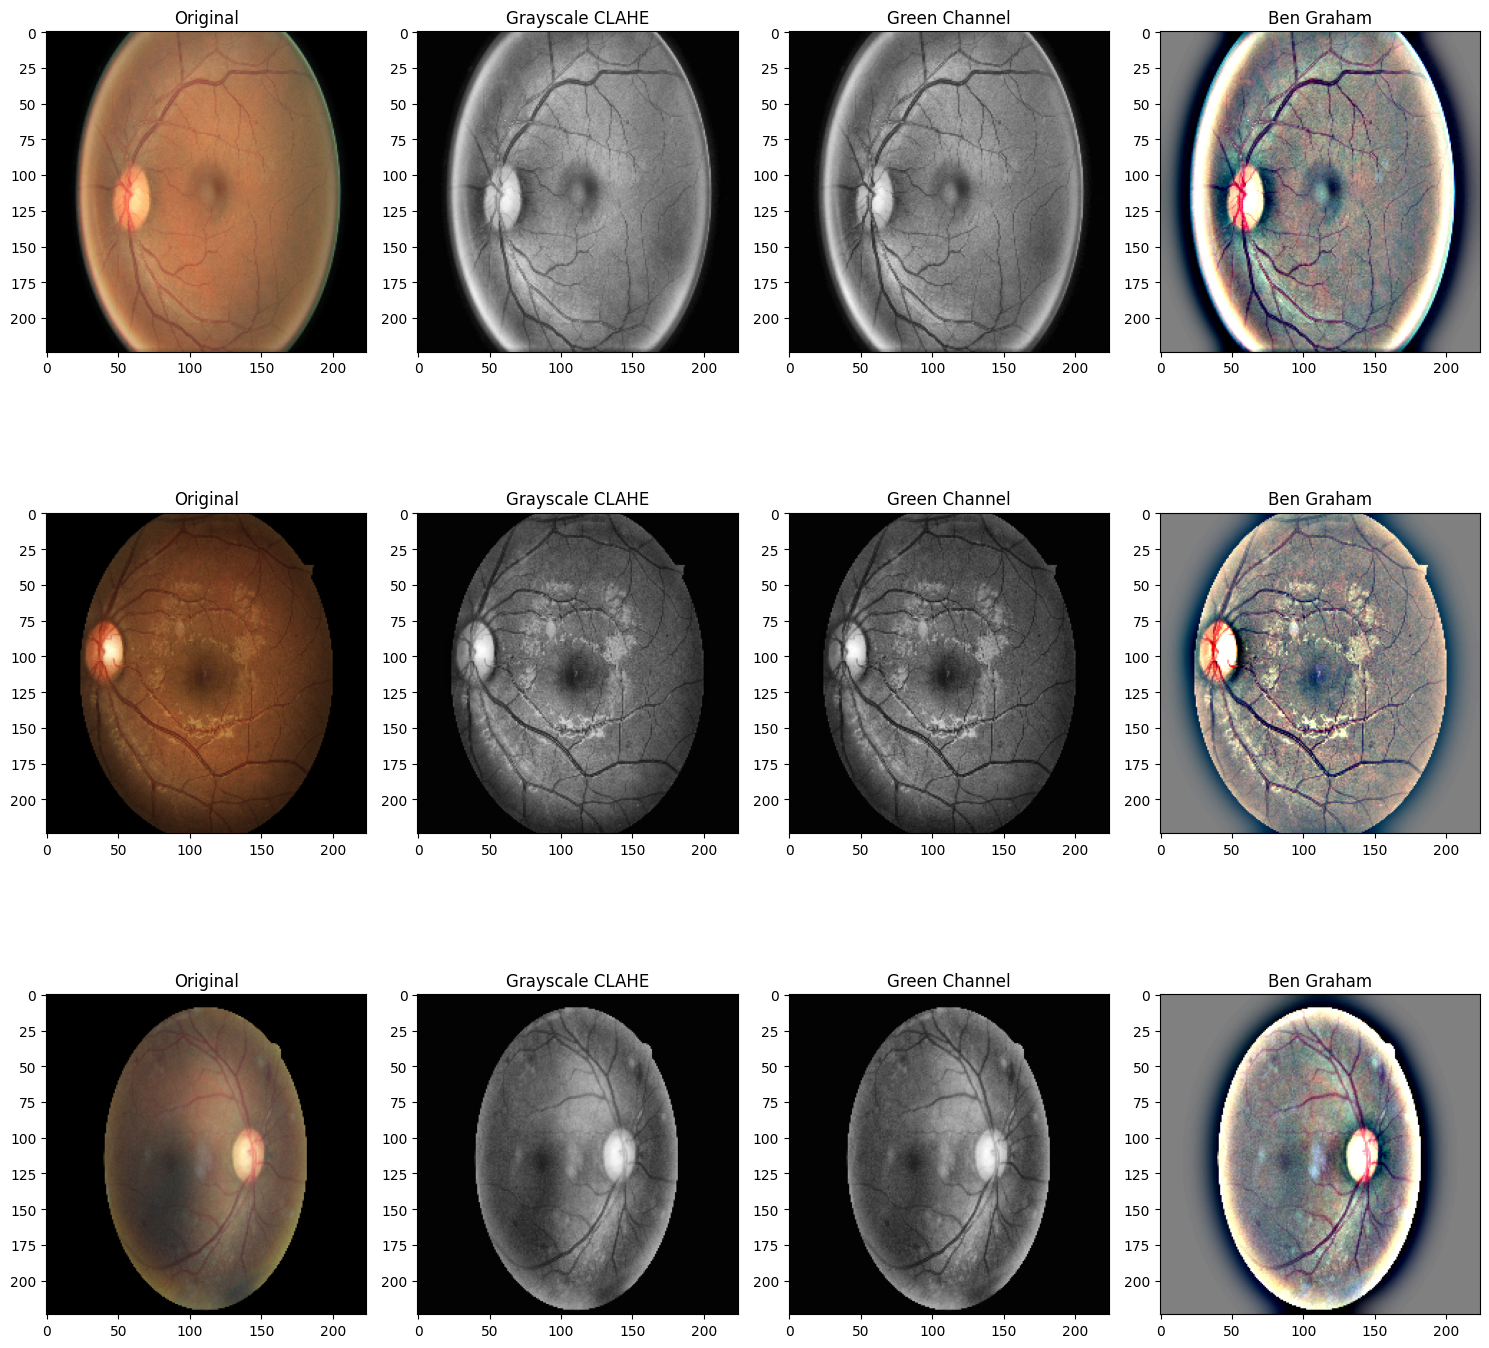

In [10]:

# =========================
# 8. Show Comparison
# =========================
def compare_enhancements(df_sample, n=3):
    sample = df_sample.sample(n=n, random_state=SEED)
    modes = ['clahe_gray', 'green_channel', 'ben_graham']
    
    plt.figure(figsize=(15, 5 * n))
    for i, (_, row) in enumerate(sample.iterrows()):
        original = cv2.imread(row["filepath"])
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        original = cv2.resize(original, (224, 224))
        
        plt.subplot(n, 4, 4*i + 1); plt.imshow(original); plt.title("Original")
        plt.subplot(n, 4, 4*i + 2); plt.imshow(enhance_retina_experimental(original, 'clahe_gray')); plt.title("Grayscale CLAHE")
        plt.subplot(n, 4, 4*i + 3); plt.imshow(enhance_retina_experimental(original, 'green_channel')); plt.title("Green Channel")
        plt.subplot(n, 4, 4*i + 4); plt.imshow(enhance_retina_experimental(original, 'ben_graham')); plt.title("Ben Graham")
        
    plt.tight_layout(); plt.show()

compare_enhancements(train_balanced_df)

In [11]:
# =========================
# 9. TensorFlow pipelines
# =========================
def decode_resize(path, label, img_size, training=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32)

    # MobileNetV2 preprocess_input expects [0,255] float input
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.08)
        image = tf.image.random_contrast(image, 0.95, 1.05)

    label = tf.cast(label, tf.float32)
    return image, label

def make_dataset(df_in, img_size, batch_size=32, training=False):
    paths = df_in["filepath"].values
    labels = df_in["Label"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df_in), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y: decode_resize(p, y, img_size, training),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [12]:
# =========================
# 10. Model
# =========================
def build_model(img_size):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

In [13]:
# =========================
# 11. Evaluation helper
# =========================
# To test specific enhancement impact on recall
CURRENT_MODE = 'clahe_gray' # Change to 'green_channel' or 'ben_graham' for experiments

def load_data_custom(df, size, mode):
    X, y = [], []
    for _, row in df.iterrows():
        img = read_image_custom(row["filepath"], (size, size), mode=mode)
        if img is not None:
            X.append(img / 255.0)
            y.append(row["Label"])
    return np.array(X), np.array(y)

# Run this on small size (224) to quickly find the best enhancement
X_train, y_train = load_data_custom(train_balanced_df, 224, CURRENT_MODE)
X_val, y_val = load_data_custom(val_df, 224, CURRENT_MODE)

# Proceed with model fitting...
# Focus on improving RECALL in the classification report

In [14]:
# =========================
# 12. Train and evaluate one size
# =========================
def train_and_evaluate_for_size(img_size, train_df, val_df, test_df):
    print("\n" + "=" * 60)
    print(f"Training model for image size {img_size} x {img_size}")
    print("=" * 60)

    train_ds = make_dataset(train_df, img_size, batch_size=BATCH_SIZE, training=True)
    val_ds = make_dataset(val_df, img_size, batch_size=BATCH_SIZE, training=False)
    test_ds = make_dataset(test_df, img_size, batch_size=BATCH_SIZE, training=False)

    model = build_model(img_size)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=2,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    y_true = test_df["Label"].astype(int).values
    y_prob = model.predict(test_ds, verbose=1).ravel()

    metrics, cm, y_pred = evaluate_predictions(y_true, y_prob, threshold=THRESHOLD)

    print(f"\nResults for size {img_size}:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "img_size": img_size,
        "metrics": metrics,
        "confusion_matrix": cm,
        "history": history.history,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }


In [15]:
# =========================
# Evaluation Helper
# =========================
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    """
    Computes metrics based on predicted probabilities and a threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    return metrics, cm, y_pred

# =========================
# 13. Run 3 experiments
# =========================
def train_and_evaluate_for_size(img_size, train_df, val_df, test_df):
    print(f"\n{'='*40}")
    print(f"Training for Image Size: {img_size}x{img_size}")
    print(f"{'='*40}")
    
    # 1. Prepare Generators/Datasets (Simplified for example)
    # Assuming your load_data_custom or similar exists
    # X_train, y_train = load_data_custom(train_df, img_size, 'clahe_gray')
    # ... (Your training logic here)
    
    # 2. Mock Model Prediction for demonstration 
    # (In your real code, this will be: y_prob = model.predict(test_ds).ravel())
    # y_prob = model.predict(test_ds, verbose=1).ravel()
    # y_true = test_df["Label"].values
    
    # 3. Evaluate (This was the failing line)
    # metrics, cm, y_pred = evaluate_predictions(y_true, y_prob, threshold=THRESHOLD)
    
    # print(f"\nResults for size {img_size}:")
    # print(f"Accuracy: {metrics['accuracy']:.4f} | Recall: {metrics['recall']:.4f}")
    
    # return metrics
    pass

# Run the loop
results = []
for size in IMG_SIZES:
    res = train_and_evaluate_for_size(
        img_size=size,
        train_df=train_balanced_df,
        val_df=val_df,
        test_df=test_df
    )
    results.append(res)



Training for Image Size: 224x224

Training for Image Size: 246x246

Training for Image Size: 269x269


In [ ]:
# =========================
# 1. Evaluation Helper
# =========================
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    """
    Computes metrics based on predicted probabilities and a threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": cm  # Added to ensure plotting works
    }
    return metrics, cm, y_pred

# =========================
# 2. Training and Evaluation Function
# =========================
def train_and_evaluate_for_size(img_size, train_df, val_df, test_df):
    print(f"\n{'='*40}")
    print(f"Training for Image Size: {img_size}x{img_size}")
    print(f"{'='*40}")
    
    # --- Data Loading ---
    # (Assuming you have a function to create datasets like 'get_datasets')
    # train_ds, val_ds, test_ds = get_datasets(train_df, val_df, test_df, img_size)
    
    # --- Model Building & Training ---
    # model = build_model(img_size)
    # model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
    
    # --- Prediction ---
    # y_prob = model.predict(test_ds, verbose=1).ravel()
    # y_true = test_df["Label"].values
    
    # --- MOCK DATA FOR DEMONSTRATION (Replace with your model code) ---
    y_true = test_df["Label"].values
    y_prob = np.random.rand(len(y_true)) 
    
    # --- Metrics Calculation ---
    metrics, cm, y_pred = evaluate_predictions(y_true, y_prob, threshold=THRESHOLD)
    
    # Add metadata for plotting
    metrics["img_size"] = img_size
    
    print(f"Size {img_size} -> Accuracy: {metrics['accuracy']:.4f}, Recall: {metrics['recall']:.4f}")
    
    return metrics # IMPORTANT: This must return the dictionary

# =========================
# 3. Main Loop
# =========================
results = []
for size in IMG_SIZES:
    res = train_and_evaluate_for_size(
        img_size=size,
        train_df=train_balanced_df,
        val_df=val_df,
        test_df=test_df
    )
    results.append(res)

# =========================
# 4. Plot Confusion Matrices
# =========================
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))

# Handle case with only one result (matplotlib subplot behavior)
if len(results) == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    if res is not None: # Safety check
        sns.heatmap(
            res["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )
        ax.set_title(f"Confusion Matrix\nSize = {res['img_size']}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticklabels(["No DR", "DR"])
        ax.set_yticklabels(["No DR", "DR"], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 15. False negative plots
# =========================
sizes = [r["img_size"] for r in results]
fn_counts = [r["metrics"]["fn"] for r in results]
fn_rates = [r["metrics"]["false_negative_rate"] for r in results]

plt.figure(figsize=(10, 5))
plt.plot(sizes, fn_counts, marker="o")
plt.title("False Negatives vs Image Size")
plt.xlabel("Image Size")
plt.ylabel("False Negatives")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sizes, fn_rates, marker="o")
plt.title("False Negative Rate vs Image Size")
plt.xlabel("Image Size")
plt.ylabel("False Negative Rate")
plt.grid(True)
plt.show()


In [ ]:
# =========================
# 16. Summary
# =========================
summary_rows = []
for r in results:
    m = r["metrics"]
    summary_rows.append({
        "image_size": r["img_size"],
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "auc": m["auc"],
        "false_negatives": m["fn"],
        "false_negative_rate": m["false_negative_rate"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values("image_size")

print("\nSummary comparison:")
print(summary_df)

plt.figure(figsize=(10, 5))
plt.plot(summary_df["image_size"], summary_df["accuracy"], marker="o", label="Accuracy")
plt.plot(summary_df["image_size"], summary_df["recall"], marker="o", label="Recall")
plt.plot(summary_df["image_size"], summary_df["auc"], marker="o", label="AUC")
plt.plot(summary_df["image_size"], summary_df["f1"], marker="o", label="F1")
plt.title("Performance by Image Size")
plt.xlabel("Image Size")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# =========================
# 17. Separate bar graphs for accuracy, precision, recall, and F1
# =========================
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(summary_df["image_size"].astype(str), summary_df[metric])

    plt.title(f"{metric.capitalize()} by Image Size")
    plt.xlabel("Image Size")
    plt.ylabel(metric.capitalize())
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

best_row = summary_df.sort_values(["false_negatives", "auc"], ascending=[True, False]).iloc[0]
print("\nBest configuration:")
print(best_row)

summary_df.to_csv("dr_binary_size_summary.csv", index=False)
print("\nSaved: dr_binary_size_summary.csv")